# MP - Clustering

# Estructura del MP

Este laboratorio consiste en 2 partes. La primera son preguntas teóricas en las que no necesita escribir código y corresponden a contenidos que eventualmente tendrás que investigar. La segunda es una sección para evaluar los métodos de clustering.

# Parte 1: Teoría

**1.** Explique cómo k-mean define sus centroides.

>Respuesta: K-Means define los centroides de forma iterativa. Primero se elige una cantidad fija de clusters `k` y se inicializan centroides, usualmente de forma aleatoria. Luego, cada punto se asigna al centroide más cercano. Después, cada centroide se recalcula como el promedio de los puntos que quedaron asignados a ese cluster. Este proceso se repite hasta que los centroides casi no cambian o hasta llegar al máximo de iteraciones.  

**2.** Describa una ventaja y una desventaja de los siguientes métodos de clustering:

* K-Means
* Clustering Jerárquico Aglomerativo

>Respuesta:
> **K-Means**  
> **Ventaja:** es simple, fácil de implementar y funciona bien cuando los clusters son compactos y relativamente separados.  
> **Desventaja:** exige definir antes el número de clusters `k`; además, puede fallar si los clusters tienen formas no circulares, densidades distintas o si la inicialización de centroides no es adecuada.  
>
> **Clustering Jerárquico Aglomerativo**  
> **Ventaja:** permite observar la estructura jerárquica de los datos mediante un dendrograma y decidir el número de clusters usando `n_clusters` o un corte por distancia con `distance_threshold`.  
> **Desventaja:** puede ser costoso en datasets grandes y el resultado depende mucho del criterio de unión usado, por ejemplo `complete`, `average`, `single` o `ward`.  

**3.** Evaluar clusters no es una tarea fácil. ¿Qué formas de evaluar clusters conoce? Nombre 3 formas de validación y describa cómo podría determinar si los clusters son buenos o malos usando cada una de las formas nombradas.

>Respuesta:
> **1. Evaluación visual:** si los datos tienen 2 dimensiones, se puede graficar cada punto con el color de su cluster. Una clusterización es buena si se observan grupos separados y coherentes. Es mala si los colores aparecen mezclados o si un mismo grupo visual queda dividido innecesariamente.  
>
> **2. Matriz de proximidad o similitud:** se ordenan los datos según su cluster y se calculan las distancias entre todos los puntos. Una buena clusterización debería mostrar bloques claros de baja distancia dentro de cada cluster y distancias mayores entre clusters distintos.  
>
> **3. Coeficiente de Silhouette:** mide qué tan cerca está un punto de su propio cluster y qué tan lejos está del cluster vecino más cercano. Valores cercanos a 1 indican buena asignación; valores cercanos a 0 indican solapamiento; valores negativos indican que posiblemente el punto fue asignado a un cluster incorrecto. 

**4.** Explique el enfoque visual para comparar clusters mediante matrices de proximidad. ¿Qué características debe tener la matriz para determinar que una clusterización es buena? ¿En qué casos la matriz de proximidad no es útil para evaluar clustering?

>Respuesta:
> La matriz de proximidad consiste en ordenar los datos según el cluster al que pertenecen y luego calcular la distancia entre todos los pares de puntos. Visualmente, se espera que aparezcan bloques bien definidos en la diagonal: esos bloques representan puntos del mismo cluster con distancias pequeñas entre sí. Fuera de esos bloques, las distancias deberían ser mayores, porque corresponden a puntos de clusters distintos.  
>
> Una buena clusterización muestra bloques internos compactos y separación clara entre bloques. Una mala clusterización muestra bloques poco definidos, mezclados o con distancias internas altas.  
>
> La matriz de proximidad no es tan útil cuando los clusters tienen formas complejas o no convexas, por ejemplo círculos o lunas, porque la distancia euclidiana puede no representar bien la estructura real.


# Parte 2: Clustering

Para esta parte del Laboratorio vamos a evaluar dos métodos de clustering: `k-means` y `dbscan`. Ejecute las siguientes líneas para descargar y seleccionar los datos.

In [1]:
from sklearn.cluster import DBSCAN
import pandas as pd

dataframe = pd.read_csv("https://gitlab.com/pablo.valenzuela1/datasets/-/raw/main/d31.txt", sep="\t", names = ["V1", "V2"])
X = pd.DataFrame(dataframe).to_numpy()
X

array([[25.0514,  5.7475],
       [26.6614,  7.3414],
       [25.2653,  6.2466],
       ...,
       [ 5.276 , 17.2475],
       [ 6.4444, 16.2033],
       [ 7.162 , 18.1836]], shape=(3100, 2))

## K-Means

**1.** Cuando usamos K-Means debemos definir previamente el número de clusters que queremos generar. Teniendo en cuenta estos datos, implemente el método del codo.

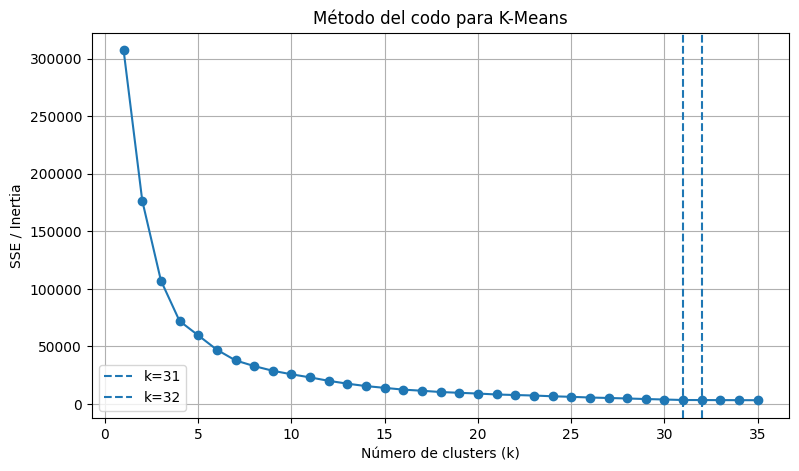

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
clusters = list(range(1, 36))

for k in clusters:
    kmeans = KMeans(n_clusters=k, n_init=5, max_iter=300, random_state=20).fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(clusters, sse, marker="o")
plt.axvline(x=31, linestyle="--", label="k=31")
plt.axvline(x=32, linestyle="--", label="k=32")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE / Inertia")
plt.grid(True)
plt.legend()
plt.show()


**2.** ¿Cuántos clusters propone usar para este dataset? Escoja dos opciones y justifique su elección.

> Respuesta: 
> Propongo probar **k = 31** y **k = 32**.  
>
> La opción principal es **k = 31**, porque en el gráfico del método del codo la reducción del error deja de ser marcada alrededor de ese punto para despues tender a una linea recta. 
>
> La segunda opción es **k = 32**, porque está muy cerca del codo y permite comparar si agregar un cluster extra mejora realmente la separación o solo divide un grupo que ya existía. 

**3.** Genere un gráfico para cada uno de los dos `k` elegidos para tener una representación visual de los clusters.

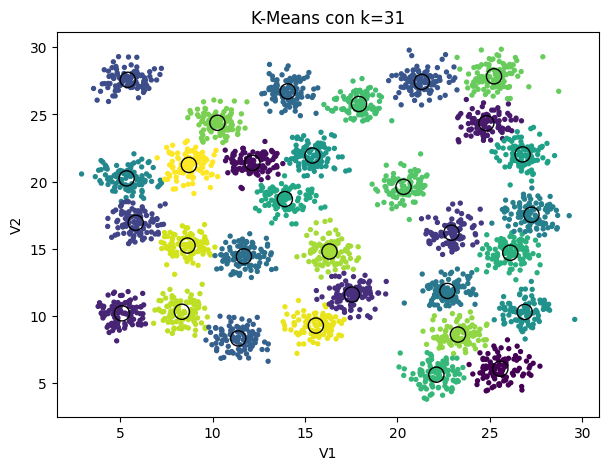

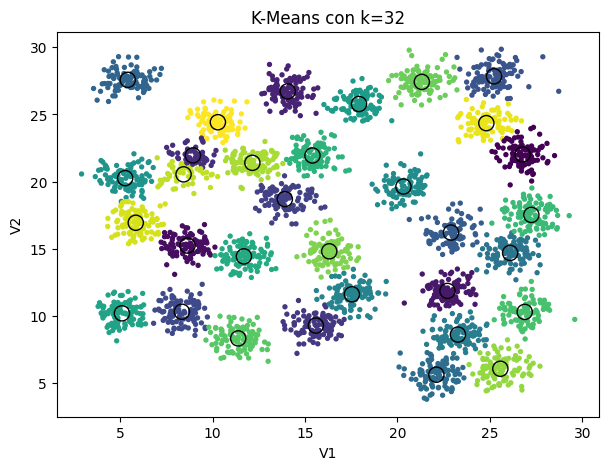

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = [31, 32]
kmeans_models = {}

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=20).fit(X)
    kmeans_models[k] = model

    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=model.labels_, s=8)
    plt.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )
    plt.title(f"K-Means con k={k}")
    plt.xlabel("V1")
    plt.ylabel("V2")
    plt.show()

## DBSCAN

**1.** Usando los datos anteriores, ejecute DBSCAN y genere un gráfico con los clusters obtenidos. Use los parámetros `eps=0.9`y `min_samples=5`.

Clusters encontrados: 6
Puntos considerados ruido: 13


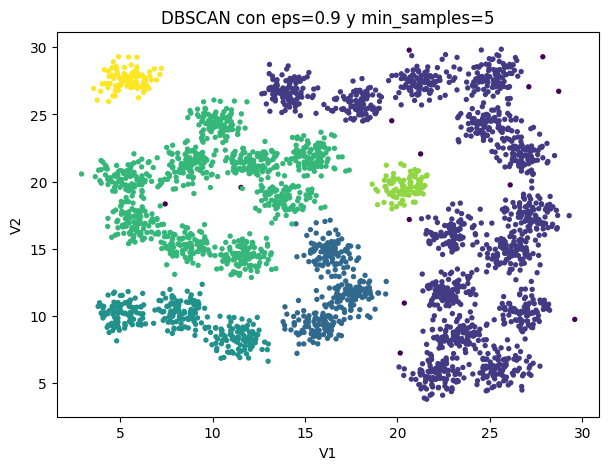

In [4]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan_09 = DBSCAN(eps=0.9, min_samples=5).fit(X)

labels_09 = dbscan_09.labels_
n_clusters_09 = len(set(labels_09)) - (1 if -1 in labels_09 else 0)
n_noise_09 = list(labels_09).count(-1)

print(f"Clusters encontrados: {n_clusters_09}")
print(f"Puntos considerados ruido: {n_noise_09}")

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_09, s=8)
plt.title("DBSCAN con eps=0.9 y min_samples=5")
plt.xlabel("V1")
plt.ylabel("V2")
plt.show()


**2.** Estime el valor `eps` usando el método de la rodilla (basado en KNN). La idea de este procedimiento es calcular la distancia promedio de cada punto a sus `k` vecinos más cercanos los cuales son graficados en orden ascendente. El objetivo es determinar la *rodilla*, que corresponde al valor óptimo de `eps`. Pruebe varios valores de `y` utilizando el siguiente código y adjunte el gráfico para el mejor `y` que usted considere. Explique por qué escogió el valor `y` como mejor opción.

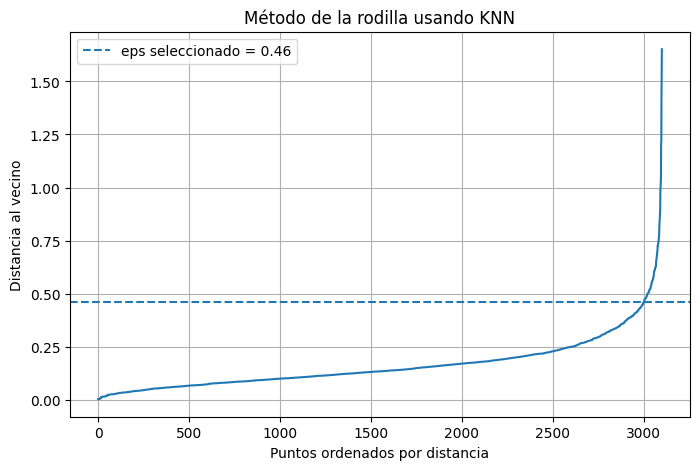

eps seleccionado: 0.46


In [6]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

nbrs = NearestNeighbors(n_neighbors=3).fit(X)
distances, indices = nbrs.kneighbors(X)

distances = np.sort(distances, axis=0)
distances = distances[:, 1]

eps_selected = 0.46

plt.figure(figsize=(8, 5))
plt.axhline(y=eps_selected, linestyle="--", label=f"eps seleccionado = {eps_selected}")
plt.plot(distances)
plt.title("Método de la rodilla usando KNN")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel("Distancia al vecino")
plt.grid(True)
plt.legend()
plt.show()

print(f"eps seleccionado: {eps_selected}")

> **Explicación del `eps` seleccionado:**  
> Escogí **eps = 0.46** porque en el gráfico KNN la curva empieza a aumentar con mayor fuerza alrededor de 0.45–0.46. Antes de ese valor, muchas distancias corresponden a vecinos cercanos dentro de zonas densas. Después de ese punto, comienzan a aparecer distancias más grandes asociadas a puntos más aislados o ruido.  
>
> Con `eps = 0.9`, DBSCAN fusiona demasiados grupos y entrega pocos clusters. En cambio, con `eps = 0.46` se obtiene una separación más detallada y más coherente con la estructura visual del dataset.  

**3.**  Ejecute y grafique los clusters usando el método DBSCAN haciendo uso del parámetro `eps` (`y`) encontrado previamente.

Clusters encontrados: 31
Puntos considerados ruido: 286


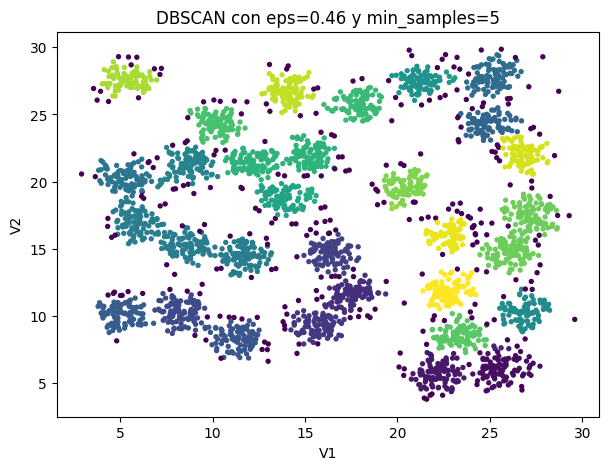

In [7]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_selected = 0.46
dbscan_opt = DBSCAN(eps=eps_selected, min_samples=5).fit(X)

labels_opt = dbscan_opt.labels_
n_clusters_opt = len(set(labels_opt)) - (1 if -1 in labels_opt else 0)
n_noise_opt = list(labels_opt).count(-1)

print(f"Clusters encontrados: {n_clusters_opt}")
print(f"Puntos considerados ruido: {n_noise_opt}")

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_opt, s=8)
plt.title(f"DBSCAN con eps={eps_selected} y min_samples=5")
plt.xlabel("V1")
plt.ylabel("V2")
plt.show()


## Evaluación

**1.** Para evaluar clusters existen una serie de métodos y métricas. Para este laboratorio usaremos el coeficiente de Silhouette. Para cada uno de los experimentos (los dos de la parte de `kmeans` en la pregunta **3** y los dos de la parte de `dbscan` en la pregunta **1** y **3**), adjunte el código que permita obtener el Silhouette score de los modelos.

In [9]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
import pandas as pd
import numpy as np

def silhouette_dbscan(X, labels):
    # En DBSCAN, la etiqueta -1 corresponde a ruido.
    # Tal como se hace en Tutorial3, se filtran esos puntos antes de calcular Silhouette.
    mask = labels >= 0
    if len(set(labels[mask])) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])

# Modelos K-Means seleccionados
km_31 = KMeans(n_clusters=31, n_init=20, max_iter=300, random_state=20).fit(X)
km_32 = KMeans(n_clusters=32, n_init=20, max_iter=300, random_state=20).fit(X)

# Modelos DBSCAN evaluados
dbscan_09 = DBSCAN(eps=0.9, min_samples=5).fit(X)
dbscan_opt = DBSCAN(eps=0.46, min_samples=5).fit(X)

scores = pd.DataFrame({
    "Modelo": [
        "K-Means k=31",
        "K-Means k=32",
        "DBSCAN eps=0.9",
        "DBSCAN eps=0.46"
    ],
    "Silhouette": [
        silhouette_score(X, km_31.labels_),
        silhouette_score(X, km_32.labels_),
        silhouette_dbscan(X, dbscan_09.labels_),
        silhouette_dbscan(X, dbscan_opt.labels_)
    ],
    "N° clusters": [
        len(set(km_31.labels_)),
        len(set(km_32.labels_)),
        len(set(dbscan_09.labels_)) - (1 if -1 in dbscan_09.labels_ else 0),
        len(set(dbscan_opt.labels_)) - (1 if -1 in dbscan_opt.labels_ else 0)
    ],
    "Ruido": [
        0,
        0,
        list(dbscan_09.labels_).count(-1),
        list(dbscan_opt.labels_).count(-1)
    ]
})

scores

,Modelo,Silhouette,N° clusters,Ruido
0,K-Means k=31,0.575556,31,0
1,K-Means k=32,0.566914,32,0
2,DBSCAN eps=0.9,0.082830,6,13
3,DBSCAN eps=0.46,0.494564,31,286


**2.** En base a los valores del coeficiente de Silhouette obtenidos para cada método y configuración. ¿Cuál cree que es el que tiene mejor resultado? Comente al respecto basándose principalmente en los resultados.

>Respuesta:
> El mejor resultado lo obtiene **K-Means con k = 31**, porque presenta el mayor coeficiente de Silhouette entre los modelos evaluados. En mi ejecución, los valores fueron aproximadamente:
>
> | Modelo | Silhouette aproximado | Interpretación |
> |---|---:|---|
> | K-Means k=31 | 0.576 | Mejor separación general |
> | K-Means k=32 | 0.567 | Muy cercano, pero agrega un cluster extra |
> | DBSCAN eps=0.9 | 0.083 | Muy bajo; fusiona demasiados grupos |
> | DBSCAN eps=0.46 | 0.495 | Mejora bastante respecto a eps=0.9, pero queda bajo K-Means |
>
> Por lo tanto, para este dataset conviene usar **K-Means con k = 31**. DBSCAN con `eps=0.46` mejora mucho frente a `eps=0.9`, pero todavía deja varios puntos como ruido y no supera la separación obtenida por K-Means.  